In [2]:
# Run with flood conda env
# Requires previous running of process_S2.ipynb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import pickle
from PIL import Image
import string

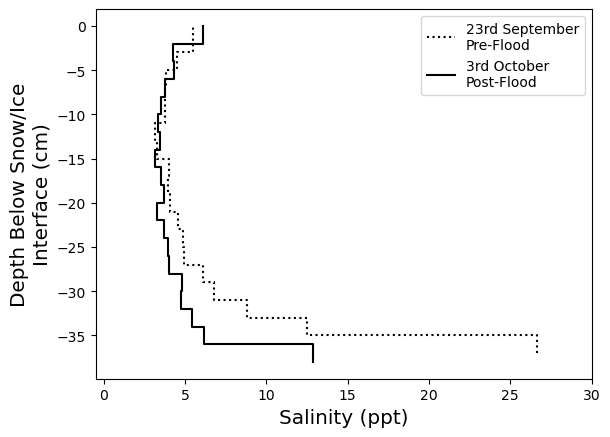

In [10]:
def make_core_plot(ax):

    df03=pd.read_excel('../../data/Flood_geophys.ods',sheet_name=f'core03',header=None)
    df23=pd.read_excel('../../data/Flood_geophys.ods',sheet_name=f'core23',header=None)

    linestyles=[':','-']
    for df,date,ls in zip([df23,df03],['23rd September\nPre-Flood','3rd October\nPost-Flood'],linestyles):
        heights=[]
        temps=[]
        for h,t in zip(df.iloc[:,0],df.iloc[:,1]):
            heights += [int(x) for x in h.split('-')]
            temps.append(t)
            temps.append(t)
    
        heights = np.array(heights)
        ax.plot(temps,heights*-1,label=date,ls=ls,color='k')
    
    ax.set_xlabel(f'Salinity (ppt)',fontsize='x-large')
    ax.set_ylabel('Depth Below Snow/Ice\nInterface (cm)',fontsize='x-large')
    # ax.set_ylim(40,0)/
    ax.set_xlim(-0.5,30)
    ax.legend()

fig,ax=plt.subplots(1,1)
make_core_plot(ax)
plt.show()

(844, 844, 3)


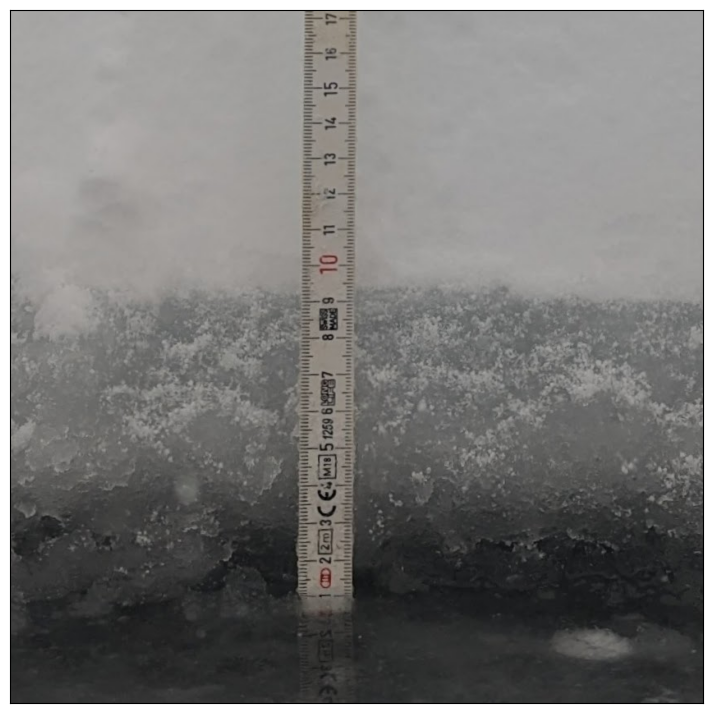

In [62]:
def make_photo(ax):
    i = Image.open(f'heavy_flood_photo.jpg')
    iar = np.array(i)[1050:-150,600:-600]
    print(iar.shape)
    ax.imshow(iar)
    ax.set_xticks([])
    ax.set_yticks([])

fig = plt.figure(figsize=(9,9))

ax = fig.add_subplot(1,1,1)
make_photo(ax)


/home/robbie/anaconda3/envs/flood/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)


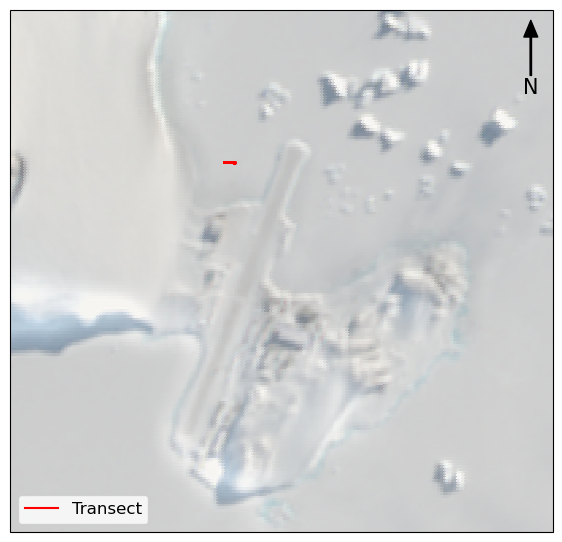

In [63]:
def make_S2_panel(ax1):

    lonlat=pickle.load(open('xytrans.p','rb'))
    
    (basemap,longrid,latgrid) = pickle.load(open('S2.p','rb'))
    
    lat_off=0.001
    lon_off=0.018
    
    # Reshape as list of rgb tuples
    color_tuples = (np.array([basemap[0][::2,::2].flatten(),
                             basemap[1][::2,::2].flatten(),
                             basemap[2][::2,::2].flatten()])/65000).transpose()
    
    
    ax1.set_extent([np.max(longrid)-lon_off,
                    np.min(longrid)+lon_off/3,
                    np.min(latgrid)+lat_off,
                    np.max(latgrid)-lat_off],
                   ccrs.PlateCarree())
    
    ax1.pcolormesh(longrid[::2,::2],latgrid[::2,::2],basemap[0][::2,::2],
                   color=color_tuples,     
             transform=ccrs.PlateCarree(),
                   zorder=2,
                  )
    
    transect=ax1.scatter(lonlat[0],lonlat[1]+0.0005,
               color='r',s=1,marker='.',
             transform=ccrs.PlateCarree(),
                zorder=10,cmap='grey')
    
    ax1.plot([],[],color='r',label='Transect')
    
    arrow_length = 10
    ax1.annotate('N',
            xy=(0.96,0.98),
            xytext=(0.96,0.85),
            arrowprops=dict(facecolor='black',
                            width=1, headwidth=10),
            ha='center',
            va='center',
            fontsize=15,
            xycoords='axes fraction')
    
    ax1.legend(loc='lower left',
               fontsize='large')

fig = plt.figure(figsize=(7,7))

ax1 = fig.add_subplot(1,1,1,
                      projection=ccrs.SouthPolarStereo(central_longitude=-68))

make_S2_panel(ax1)

In [64]:
def make_NH_map(ax):
    
    (cont_x,cont_y,cont_data,lons,lats,data,
         sicdatax,sicdatay,sic) = pickle.load(open('lanqing/NH_plot.p','rb'))
    
    proj = ccrs.NorthPolarStereo()
    maxlat=90
    
    ax.set_extent([-2.5e6, 1e6, -3e6, 0e6], ccrs.epsg('3413'))
    
    # SEA ICE CONCENTRATION
    
    m = ax.pcolormesh(sicdatax,sicdatay,sic,
                     transform=ccrs.epsg('3413'),cmap='tab20c',
                      vmin=0,vmax=1,
                      zorder=0)
    
    ax.add_feature(cartopy.feature.LAND, edgecolor='None',zorder=0,alpha=0.6,color='beige')
    
    ax.coastlines(resolution='50m',zorder=10,color='k',linewidth=0.3)
    
    q=100
    data[data==0]=np.nan
    
    coords = {'chch':(58.76841, -94.16496),
              'resolute':(74.6973, -94.8297),
              'mosaic':(87.397845, 98.418585)}
    
    names = ['Churchill','Resolute','MOSAiC']
    colors=['green','red','purple']
    markers=['o','s','^']
    for marker,name,color,(key,value) in zip(markers,names,colors,coords.items()):
        m = ax.scatter(value[1],
                      value[0],
                       s=200,
                       linewidth=2,
                       facecolor="None",
                     transform=ccrs.PlateCarree(),
                      color=color,label=name,marker=marker,
                      zorder=200)
    
    
    ax.legend(loc='upper right',
              fontsize='large',framealpha=1,labelspacing=1.02)
    
def make_SH_map(ax2):
    
    (cont_x,cont_y,cont_data,lons,lats,data,
     sicdatax,sicdatay,sic) = pickle.load(open('lanqing/plot.p','rb'))
    
    maxlat=90
    
    ax2.add_feature(cartopy.feature.LAND, edgecolor='None',zorder=30,alpha=0.3,color='beige')
    
    ax2.coastlines(resolution='50m',zorder=310,color='k',linewidth=0.5)
    
    ax2.set_extent([-3e6, -1e6, 0, 2e6], ccrs.epsg('3412'))
    
    q=300
    m = ax2.pcolormesh(lons[q:-q,q:-q],
                      lats[q:-q,q:-q],
                      data[q:-q,q:-q],
                     transform=ccrs.PlateCarree(),
                      cmap='coolwarm_r',
                      vmin=0,vmax=150,
                      zorder=20)
    
    
    m = ax2.contour(cont_x[q:-q,q:-q],
                      cont_y[q:-q,q:-q],
                      cont_data[q:-q,q:-q],
                     transform=ccrs.epsg(3409),
                        levels=[50],linewidths=[0.3],
                      zorder=90)
    
    m = ax2.pcolormesh(sicdatax,sicdatay,sic,
                     transform=ccrs.epsg('3412'),cmap='tab20c',
                      vmin=0,vmax=1,
                      zorder=0)
    
    ax2.scatter([-68.1242],[-67.568],transform=ccrs.PlateCarree(),
               color='darkorange',s=150,marker='D',facecolor="None",linewidth=2,
               zorder=400,label='Rothera\nResearch\nStation')
    
    ax2.legend(loc='upper right',
              fontsize='large',framealpha=1)
    

In [65]:
data_dir='../../data/Flood_geophys.ods'
m=r'$\degree$'

def make_temp_plot_before(ax,legend=False):
    
    df=pd.read_excel(data_dir,sheet_name='23_temp')
    
    colors=['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink']
    
    for col,c in zip(df.columns,colors):
        
        l = df[col]
        ax.scatter([l[4]],[0],marker='o',color=c,s=60,fc='none')
        ax.scatter([l[0]],[6],marker='^',color=c,s=60,fc='none')
    
        ax.plot([l[4],l[3],l[3],l[2],l[2],l[1],l[1],l[0]],[0,0,2,2,4,4,6,6],color=c,label=f'P{col}',linestyle='-')

    ax.set_xlabel(f'Temperature ({m}C)',fontsize='x-large')
    ax.set_ylabel(f'Height Above Ice (cm)',fontsize='x-large')

    
    ax.scatter([],[],marker='o',color='k',label='Snow/Ice\nInterface',fc='none')
    ax.scatter([],[],marker='^',color='k',label='Air/Snow\nInterface',fc='none')
    ax.set_xlim(-13,-1)

    if legend:ax.legend(ncols=2)

def make_sal_plot_before(ax,legend=False):

    df=pd.read_excel('../../data/Flood_geophys.ods',sheet_name='23_salinity')
    
    colors=['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink']
    
    for col,c in zip(df.columns,colors):
        
        l = df[col]
        ax.scatter([l[3]],[0],marker='s',color=c,s=60,fc='none')
    
        ax.plot([l[3],l[2],l[2],l[1],l[1],l[0],l[0]],[0,0,2,2,4,4,6],color=c,label=f'P{col}',linestyle='-')

    ax.scatter([],[],marker='s',color='k',label='Ice Surface\nScraping',fc='none')
    
    ax.set_xlabel(f'Salinity (ppt)')
    ax.set_ylabel(f'Height Above Ice (cm)',fontsize='x-large')
    ax.set_xlim(-0.5,30)
    
    if legend:ax.legend(ncols=2)

def plot_temp(ax,df,num,ice_surf_temp,snow_surf_temp,color):
    
    df=df.iloc[1:-1]
    
    heights=[]
    temps=[]

    for h,t in zip(df.iloc[:,0],df.iloc[:,1]):
        heights += [int(x) for x in h.split('-')]
        temps.append(t)
        temps.append(t)
        
    ax.plot([snow_surf_temp]+temps+[ice_surf_temp],[heights[0]]+heights+[0],
            # label=f'P{num}',
            color=color,ls='-',label=f'P{num}')
    ax.scatter([ice_surf_temp],[0],color=color,marker='o',fc='none')
    ax.scatter([snow_surf_temp],[heights[0]],color=color,marker='^',fc='none')

def make_temp_plot_after(ax):

    ice_surf_temps=[-2.1,-1.9,-2.2,-2.0,-2.0,-2.0,-2]
    snow_surf_temps = [-7.8,-7.2,-7.2,-7.4,-7.1,-7.3,-7.6]
        
    colors=['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink']
        
    for i,c in zip(range(1,8),colors):
    
        df=pd.read_excel('../../data/Flood_geophys.ods',sheet_name=f'p{i}_temp',header=None)
    
        plot_temp(ax,df,i,ice_surf_temp=ice_surf_temps[i-1],snow_surf_temp=snow_surf_temps[i-1],color=c)
        # make_temp_plot(ax)
    
    ax.scatter([],[],marker='o',color='k',label='Snow/Ice\nInterface',fc='none')
    ax.scatter([],[],marker='^',color='k',label='Air/Snow\nInterface',fc='none')

    # ax.plot([],[],color='k',ls='-',label='Before')
    # ax.plot([],[],color='k',ls='-',label='After')
    
    ax.legend(ncols=2)
    ax.set_xlabel(f'Temperature ({m}C)',fontsize='x-large')
    ax.set_ylabel('Height Above Ice (cm)',fontsize='x-large')
    ax.set_xlim(-12,0)


def make_sal_plot_after(ax):

    for num in range(1,8):
        df=pd.read_excel('../../data/Flood_geophys.ods',sheet_name=f'p{num}_sal',header=None)
        heights=[]
        temps=[]
        for h,t in zip(df.iloc[:,0],df.iloc[:,1]):
            heights += [int(x) for x in h.split('-')]
            temps.append(t)
            temps.append(t)
            
        ax.plot(temps,heights,label=f'P{num}',ls='-')
    
    ax.set_xlabel(f'Salinity (ppt)',fontsize='x-large')
    ax.set_ylabel('Height Above Ice (cm)',fontsize='x-large')
    ax.legend(ncols=2)
    ax.set_xlim(-0.5,30)

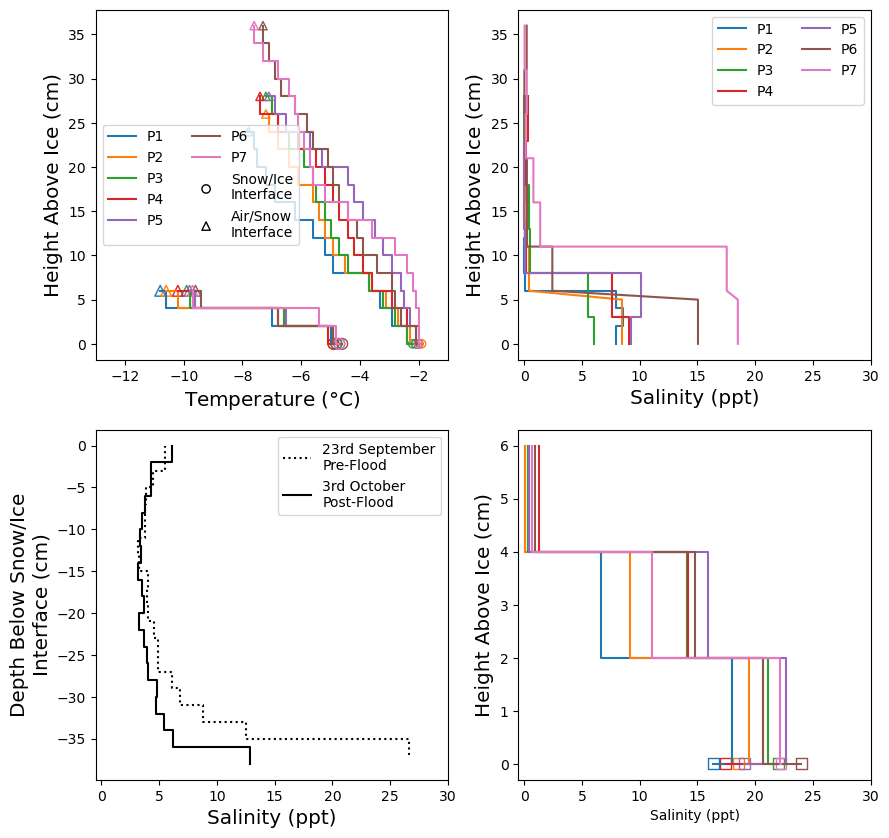

In [66]:
fig,axs=plt.subplots(2,2,figsize=(10,10))

ax1,ax2,ax3,ax4=axs.reshape(-1)

make_temp_plot_after(ax1)
make_temp_plot_before(ax1)

make_sal_plot_after(ax2)

make_sal_plot_before(ax4)

make_core_plot(ax3)

plt.show()


/home/robbie/anaconda3/envs/flood/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)


(844, 844, 3)


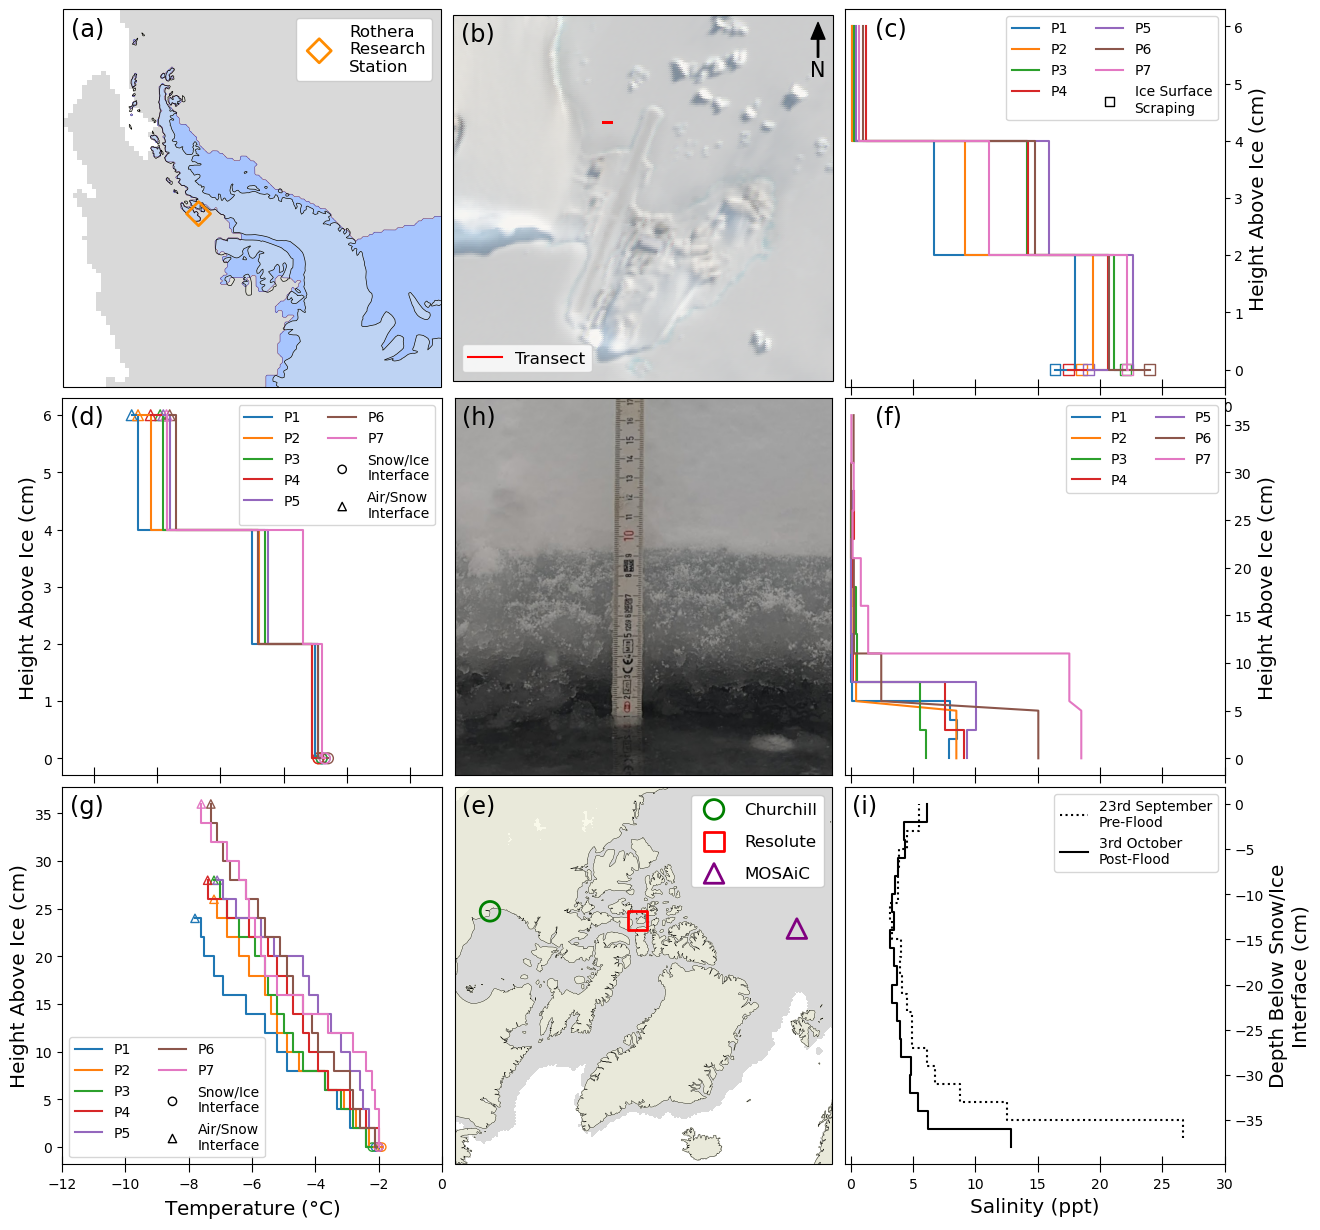

In [69]:
fig = plt.figure(figsize=(15,15))

ax1 = fig.add_subplot(3,3,1,projection=ccrs.SouthPolarStereo())

ax5 = fig.add_subplot(3,3,8,projection=ccrs.NorthPolarStereo())
ax2 = fig.add_subplot(3,3,2,
                      projection=ccrs.SouthPolarStereo(central_longitude=-68))


ax3 = fig.add_subplot(3,3,3)
ax4 = fig.add_subplot(3,3,4)
ax6 = fig.add_subplot(3,3,6)
ax7 = fig.add_subplot(3,3,7)
ax8 = fig.add_subplot(3,3,5)
ax9 = fig.add_subplot(3,3,9)


make_SH_map(ax1)

make_NH_map(ax5)

make_S2_panel(ax2)

make_sal_plot_before(ax3,legend=True)

make_photo(ax8)

make_sal_plot_after(ax6)

make_temp_plot_after(ax7)
make_temp_plot_before(ax4,legend=True)

make_core_plot(ax9)

for ax in [ax3,ax6,ax9]:
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position('right')

for ax in [ax3,ax6,ax9,ax4,ax7]:    
    ax.tick_params(axis='x',direction='inout',size=12)

letters = string.ascii_lowercase
for ax,letter in zip([ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9],letters):
    if letter in ['c','f']:
        xcoord=0.08
    else:
        xcoord=0.02
    ax.annotate(f'({letter})',
                fontsize='xx-large',
                xy=(xcoord,0.98),va='top',xycoords='axes fraction')

for ax in [ax4,ax6]: ax.set_xticklabels([])
    
plt.subplots_adjust(wspace=0.03,hspace=0.03)


over_dir = '/home/robbie/Dropbox/Apps/Overleaf/Rothera_flooding/figures/'

plt.savefig(f'{over_dir}F1_square.png',dpi=500,bbox_inches='tight')

plt.show()

/home/robbie/anaconda3/envs/flood/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)


(844, 844, 3)


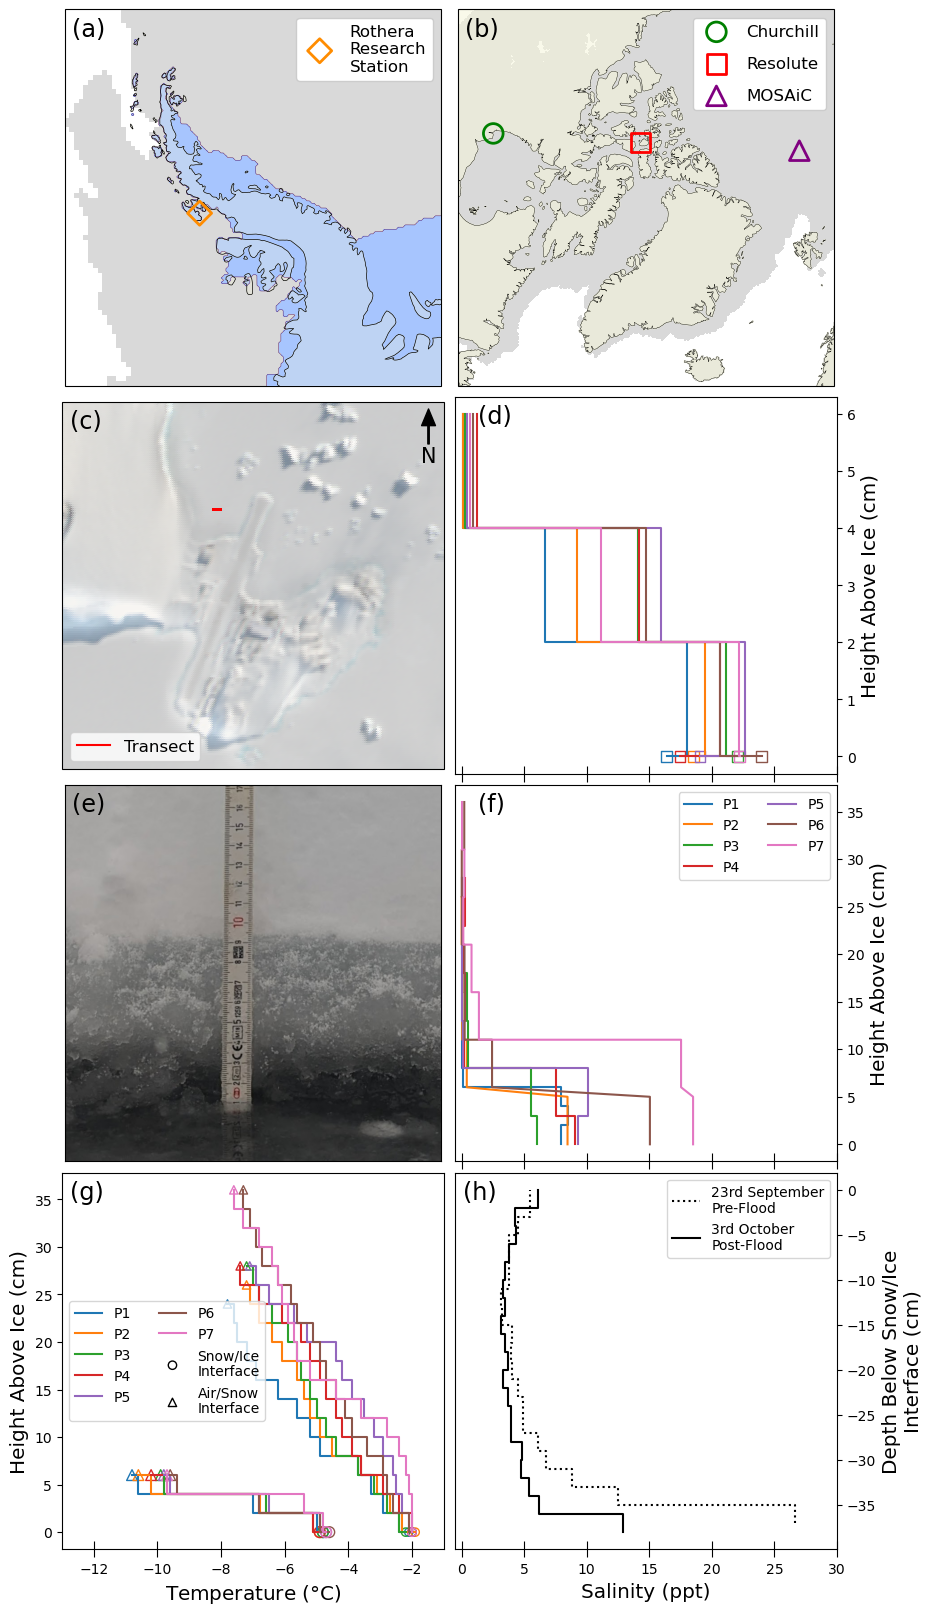

In [68]:
fig = plt.figure(figsize=(10,20))

ax1 = fig.add_subplot(4,2,1,projection=ccrs.SouthPolarStereo())
ax2 = fig.add_subplot(4,2,2,projection=ccrs.NorthPolarStereo())
ax3 = fig.add_subplot(4,2,3,
                      projection=ccrs.SouthPolarStereo(central_longitude=-68))


ax4 = fig.add_subplot(4,2,4)
ax5 = fig.add_subplot(4,2,5)
ax6 = fig.add_subplot(4,2,6)
ax7 = fig.add_subplot(4,2,7)
ax8 = fig.add_subplot(4,2,8)

make_SH_map(ax1)

make_NH_map(ax2)

make_S2_panel(ax3)

make_sal_plot_before(ax4)

make_photo(ax5)

make_sal_plot_after(ax6)

make_temp_plot_after(ax7)
make_temp_plot_before(ax7)

make_core_plot(ax8)

for ax in [ax4,ax6,ax8]:
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position('right')

for ax in [ax4,ax6,ax8,ax7]:    
    ax.tick_params(axis='x',direction='inout',size=12)

letters = string.ascii_lowercase
for ax,letter in zip([ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8],letters):

    if letter in ['d','f']:
        xcoord=0.06
    else:
        xcoord=0.02
    ax.annotate(f'({letter})',
                fontsize='xx-large',
                xy=(xcoord,0.98),va='top',xycoords='axes fraction')

for ax in [ax4,ax6]: ax.set_xticklabels([])
    
plt.subplots_adjust(wspace=0.03,hspace=0.03)


over_dir = '/home/robbie/Dropbox/Apps/Overleaf/Rothera_flooding/figures/'

plt.savefig(f'{over_dir}F1.png',dpi=500,bbox_inches='tight')

plt.show()